In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
print("racine du projet :", ROOT)

df = pd.read_parquet(ROOT / "data" / "processed" / "paysim.parquet")
df.head()

racine du projet : C:\Users\latro\fraudlens


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [4]:
print(df.shape)
print("fraudes :", df["isFraud"].sum(), "| taux :", df["isFraud"].mean())

(6362620, 10)
fraudes : 8213 | taux : 0.001290820448180152


In [5]:
df.groupby("type", observed=True)["isFraud"].agg(["count", "sum", "mean"])

,count,sum,mean
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.001840
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.007688


count    743.000000
mean      11.053836
std        4.998631
min        0.000000
25%        8.000000
50%       10.000000
75%       14.000000
max       40.000000
Name: isFraud, dtype: float64


<Axes: title={'center': 'Fraudes par heure (step)'}, xlabel='step'>

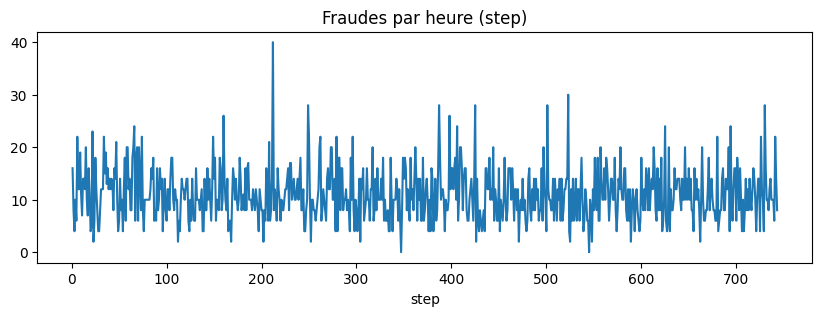

In [6]:
fraud_per_step = df.groupby("step")["isFraud"].sum()
print(fraud_per_step.describe())
fraud_per_step.plot(figsize=(10, 3), title="Fraudes par heure (step)")

             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


<Axes: >

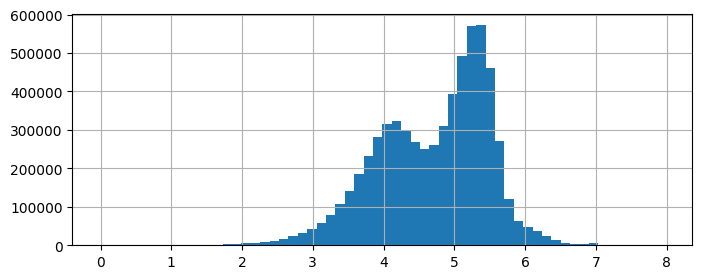

In [7]:
print(df.groupby("isFraud")["amount"].describe())
np.log10(df["amount"] + 1).hist(bins=60, figsize=(8, 3))

In [8]:
print("nameOrig uniques :", df["nameOrig"].nunique(), "sur", len(df))
print("nameDest uniques :", df["nameDest"].nunique(), "sur", len(df))
print(df["nameDest"].value_counts().head())

nameOrig uniques : 6353307 sur 6362620
nameDest uniques : 2722362 sur 6362620
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
Name: count, dtype: int64
